# Experiment: CyEmbed Archetype Embedding Analysis (Breast CyTOF + VIM)


Interpretation and QC notebook for one saved run from `01_archetype_embedding_sweep.ipynb`.

Sections A-I:
- A. Reconstruction QC
- B. Archetype profiles
- C. Per-cell weights
- D. Sample-level summaries
- E. Cluster-level summaries
- F. UMAP overlays
- G. Marker embedding analysis
- H. Archetype embedding analysis
- I. Residual analysis


In [16]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from CyEmbed.analysis import (
    archetype_marker_rankings,
    cosine_similarity_matrix,
    dominant_assignments,
    load_run_outputs,
    nearest_neighbors_from_similarity,
    pairwise_distance_matrix,
    pca_projection,
    per_marker_reconstruction_stats,
    purity_summary,
    residual_summary,
    summarize_by_group,
    umap_projection,
    weight_entropy,
)
from CyEmbed.plotting import (
    plot_embedding_scatter,
    plot_clustermap,
    plot_matrix_heatmap,
    plot_observed_vs_reconstructed,
    plot_umap_categorical,
    plot_umap_overlay,
    plot_weight_histograms,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


sns.set_theme(context="notebook", style="whitegrid")


In [17]:
# === Editable configuration ===
SWEEP_ROOT = Path("outputs/breast_vim_archetype_embedding_sweep")
RUN_DIR = None  # Optional explicit run dir path
RUN_ID = None   # Optional explicit run_id (used when RUN_DIR is None)

ANALYSIS_OUTDIR = Path("outputs/breast_vim_archetype_embedding_analysis")
ANALYSIS_OUTDIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_CFG = {
    "top_n_markers": 20,
    "scatter_markers": None,  # None -> pick top markers by R2
    "row_zscore_archetype_heatmap": True,
    "max_umap_panels": 12,

    # Run discovery/selection while sweep is still running
    # Options: "composite" or any column from runs_df (e.g. "val_recon")
    "run_selection_metric": "composite",
    "require_no_dead_archetypes": True,
    "dead_archetype_threshold": 0,
    "composite_weights": {
        "val_recon": 1.0,
        "dead_archetypes": 2.0,
        "usage_std": 0.5,
        "mean_entropy": 0.25,
        "purity": 0.25,
    },

    # Optional AnnData path for UMAP overlays / conditions
    "adata_path": "/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/breast_cytof_withvim_processed.h5ad",
    "condition_col": None,
}


In [18]:
# === Load run outputs ===
required_files = [
    "config.json",
    "summary_metrics.json",
    "history.csv",
    "X_observed.npy",
    "X_hat.npy",
    "W.npy",
    "A_hat.npy",
    "marker_names.csv",
    "cell_ids.csv",
]


def _discover_completed_runs(sweep_root: Path) -> pd.DataFrame:
    run_records = []
    if not sweep_root.exists():
        return pd.DataFrame()

    for run_dir in sorted([d for d in sweep_root.iterdir() if d.is_dir()]):
        if not all((run_dir / f).exists() for f in required_files):
            continue

        try:
            with (run_dir / "config.json").open("r", encoding="utf-8") as f:
                cfg = json.load(f)
            with (run_dir / "summary_metrics.json").open("r", encoding="utf-8") as f:
                sm = json.load(f)
            history = pd.read_csv(run_dir / "history.csv")
        except Exception as exc:
            print(f"Skipping unreadable run folder {run_dir.name}: {exc}")
            continue

        val_summary = sm.get("val", {})
        val_recon = sm.get("best_val_recon", sm.get("final_val_recon", np.nan))
        run_records.append(
            {
                "run_id": sm.get("run_id", run_dir.name),
                "run_dir": str(run_dir.resolve()),
                "decoder_type": cfg.get("decoder_type"),
                "K": cfg.get("K"),
                "d": cfg.get("d"),
                "hidden_dims": cfg.get("hidden_dims"),
                "lr": cfg.get("lr"),
                "batch_size": cfg.get("batch_size"),
                "recon_loss_type": cfg.get("recon_loss_type"),
                "tau": cfg.get("tau"),
                "patience": cfg.get("patience"),
                "best_epoch": sm.get("best_epoch", np.nan),
                "stopped_early": sm.get("stopped_early", np.nan),
                "val_recon": val_recon,
                "final_val_recon": sm.get("final_val_recon", np.nan),
                "dead_archetypes": val_summary.get("dead_archetypes_lt_1pct", np.nan),
                "usage_std": val_summary.get("usage_std", np.nan),
                "mean_entropy": val_summary.get("mean_weight_entropy", np.nan),
                "purity_gt_08": val_summary.get("dominant_frac_gt_0_8", np.nan),
                "n_epochs_completed": int(history["epoch"].max()) if "epoch" in history.columns and len(history) > 0 else 0,
            }
        )

    if not run_records:
        return pd.DataFrame()

    runs_df = pd.DataFrame(run_records)
    return runs_df


def _add_composite_score(runs_df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    w = cfg["composite_weights"]
    out = runs_df.copy()
    out["composite_score"] = (
        w["val_recon"] * out["val_recon"].astype(float)
        + w["dead_archetypes"] * out["dead_archetypes"].astype(float)
        + w["usage_std"] * out["usage_std"].astype(float)
        + w["mean_entropy"] * out["mean_entropy"].astype(float)
        - w["purity"] * out["purity_gt_08"].astype(float)
    )
    return out


runs_df = _discover_completed_runs(SWEEP_ROOT)
if runs_df.empty:
    raise FileNotFoundError(
        f"No completed runs found in {SWEEP_ROOT}. "
        "Start the sweep notebook first, or wait for at least one run to finish."
    )

runs_df = _add_composite_score(runs_df, ANALYSIS_CFG)

eligible_df = runs_df.copy()
if ANALYSIS_CFG.get("require_no_dead_archetypes", True):
    thr = ANALYSIS_CFG.get("dead_archetype_threshold", 0)
    filtered = eligible_df.loc[eligible_df["dead_archetypes"].fillna(np.inf) <= thr].copy()
    if not filtered.empty:
        eligible_df = filtered
    else:
        print("Warning: no runs satisfy the no-dead-archetype constraint; falling back to all completed runs.")

metric = ANALYSIS_CFG.get("run_selection_metric", "composite")
if metric == "composite":
    sort_col = "composite_score"
else:
    sort_col = metric
    if sort_col not in eligible_df.columns:
        raise ValueError(f"run_selection_metric={metric} is not a valid runs_df column.")

runs_ranked = eligible_df.sort_values(sort_col, ascending=True).reset_index(drop=True)
runs_snapshot_path = ANALYSIS_OUTDIR / "available_runs_snapshot.csv"
runs_ranked.to_csv(runs_snapshot_path, index=False)
print(f"Discovered completed runs: {len(runs_df)} | eligible for selection: {len(eligible_df)}")
print(f"Selection metric: {sort_col}")
print(f"Saved ranked run snapshot: {runs_snapshot_path}")
display(runs_ranked)

if RUN_DIR is not None:
    RUN_DIR = Path(RUN_DIR)
elif RUN_ID is not None:
    selected = runs_ranked.loc[runs_ranked["run_id"].astype(str) == str(RUN_ID)]
    if selected.empty:
        raise ValueError(f"RUN_ID={RUN_ID} was not found among ranked runs.")
    RUN_DIR = Path(selected.iloc[0]["run_dir"])
else:
    RUN_DIR = Path(runs_ranked.iloc[0]["run_dir"])

run = load_run_outputs(RUN_DIR)
X = run["X_observed"]
X_hat = run["X_hat"]
W = run["W"]
A_hat = run["A_hat"]
marker_names = run["marker_names"]
cell_ids = run["cell_ids"]

sample_ids = run.get("sample_ids")
cluster_ids = run.get("cluster_ids")

print(f"Selected run dir: {RUN_DIR}")
print(f"X shape: {X.shape}")
print(f"W shape: {W.shape}")
print(f"A_hat shape: {A_hat.shape}")
print(f"Decoder: {run['config']['decoder_type']}")

history_df = run["history"]
per_marker_df = per_marker_reconstruction_stats(X, X_hat, marker_names)
dom_df = dominant_assignments(W, cell_ids=cell_ids)
purity_df = purity_summary(W)

display(per_marker_df.head(15))
display(purity_df)


Discovered completed runs: 20 | eligible for selection: 19
Selection metric: composite_score
Saved ranked run snapshot: outputs/breast_vim_archetype_embedding_analysis/available_runs_snapshot.csv


,run_id,run_dir,decoder_type,K,d,hidden_dims,lr,batch_size,recon_loss_type,tau,patience,best_epoch,stopped_early,val_recon,final_val_recon,dead_archetypes,usage_std,mean_entropy,purity_gt_08,n_epochs_completed,composite_score
0,run015_20260416_104140,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,7,8,"[256, 128]",0.001,2048,mse,1.0,20,364,True,0.366426,0.366465,0,0.033675,1.829498,0.0,384,0.840638
1,run020_20260416_105528,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,8,12,"[256, 128]",0.001,2048,mse,1.0,20,330,True,0.335729,0.335735,0,0.035404,1.950698,0.0,350,0.841105
2,run019_20260416_105209,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,8,8,"[256, 128]",0.001,2048,mse,1.0,20,477,True,0.335768,0.336037,0,0.032884,1.961372,0.0,497,0.842553
3,run014_20260416_103808,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,7,6,"[256, 128]",0.001,2048,mse,1.0,20,558,True,0.366420,0.366442,0,0.035668,1.834601,0.0,578,0.842904
4,run016_20260416_104359,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,7,12,"[256, 128]",0.001,2048,mse,1.0,20,386,True,0.366427,0.367070,0,0.039905,1.831196,0.0,406,0.844179
5,run012_20260416_103403,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,12,"[256, 128]",0.001,2048,mse,1.0,20,317,True,0.407437,0.407447,0,0.039407,1.681469,0.0,337,0.847508
6,run011_20260416_103114,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,8,"[256, 128]",0.001,2048,mse,1.0,20,452,True,0.407440,0.407505,0,0.038353,1.688060,0.0,472,0.848632
7,run010_20260416_102828,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,6,"[256, 128]",0.001,2048,mse,1.0,20,457,True,0.407441,0.407447,0,0.038504,1.691026,0.0,477,0.849450
8,run018_20260416_104935,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,8,6,"[256, 128]",0.001,2048,mse,1.0,20,393,True,0.366396,0.366431,0,0.045589,1.860741,0.0,413,0.854375
9,run007_20260416_102053,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,5,8,"[256, 128]",0.001,2048,mse,1.0,20,410,True,0.458754,0.458798,0,0.044363,1.519939,0.0,430,0.860920


Selected run dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/breast_vim_archetype_embedding_sweep/run015_20260416_104140
X shape: (150000, 31)
W shape: (150000, 7)
A_hat shape: (7, 31)
Decoder: factorized


,marker,pearson_r,spearman_r,r2,mse,mae
0,panKeratin,0.930795,0.901649,0.866369,0.133640,0.274045
1,K8-18,0.897779,0.900878,0.805990,0.194027,0.332773
2,H3K27me2,0.872207,0.808783,0.760735,0.239273,0.372264
3,H3K4me3,0.871815,0.811776,0.760040,0.239965,0.368977
4,K5,0.862755,0.876296,0.744341,0.255669,0.336630
5,H3K36me2,0.862734,0.687643,0.744303,0.255712,0.368317
6,H3K27me3,0.861338,0.752875,0.741891,0.258115,0.392491
7,H3K27ac,0.860106,0.692614,0.739761,0.260311,0.379560
8,H2Aub,0.859466,0.587428,0.738681,0.261297,0.371939
9,EpCam,0.856416,0.815906,0.733400,0.266603,0.400761


,threshold,fraction_cells
0,0.5,0.00026
1,0.8,0.00000


,marker,pearson_r,spearman_r,r2,mse,mae
0,panKeratin,0.930795,0.901649,0.866369,0.133640,0.274045
1,K8-18,0.897779,0.900878,0.805990,0.194027,0.332773
2,H3K27me2,0.872207,0.808783,0.760735,0.239273,0.372264
3,H3K4me3,0.871815,0.811776,0.760040,0.239965,0.368977
4,K5,0.862755,0.876296,0.744341,0.255669,0.336630
5,H3K36me2,0.862734,0.687643,0.744303,0.255712,0.368317
6,H3K27me3,0.861338,0.752875,0.741891,0.258115,0.392491
7,H3K27ac,0.860106,0.692614,0.739761,0.260311,0.379560
8,H2Aub,0.859466,0.587428,0.738681,0.261297,0.371939
9,EpCam,0.856416,0.815906,0.733400,0.266603,0.400761


,marker,pearson_r,spearman_r,r2,mse,mae
30,gH2AX,0.526357,0.488494,0.277041,0.722949,0.646834
29,CD44,0.624633,0.499193,0.390154,0.609801,0.571764
28,ECad,0.641090,0.587615,0.410990,0.588972,0.573781
27,CD49f,0.693996,0.721814,0.481629,0.518354,0.553214
26,H3S28p,0.703281,0.691207,0.494601,0.505419,0.557279
25,Ki67,0.717541,0.602658,0.514838,0.485168,0.504020
24,CD24,0.736978,0.781738,0.543107,0.456778,0.545038
23,H3K4me1,0.759687,0.713756,0.577116,0.422896,0.498448
22,H3K36me3,0.766380,0.765222,0.587300,0.412715,0.500699
21,H3K9ac,0.768270,0.658439,0.590232,0.409842,0.488078


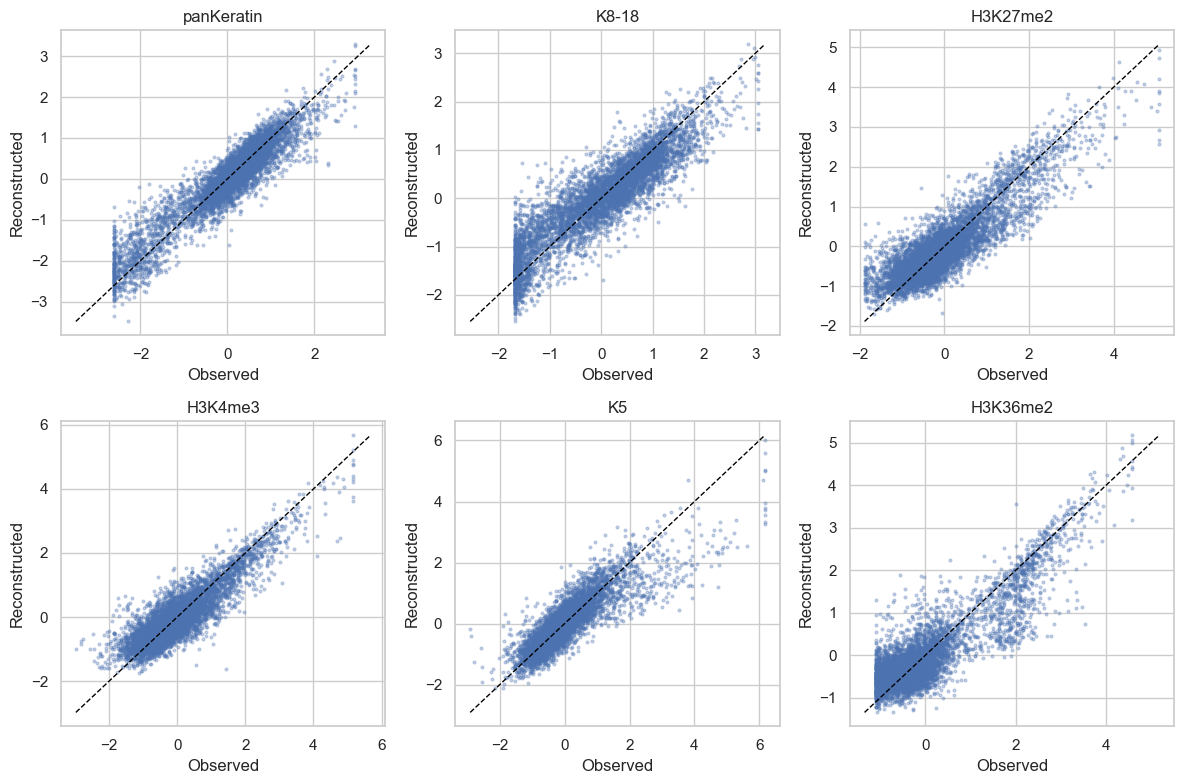

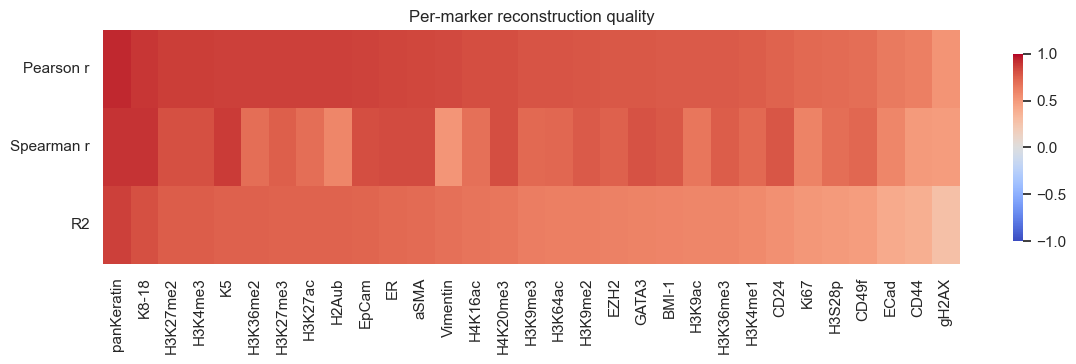

In [19]:
# === A) Reconstruction QC ===
selected_markers = ANALYSIS_CFG["scatter_markers"]
if selected_markers is None:
    selected_markers = per_marker_df.head(min(6, len(marker_names)))["marker"].tolist()

plot_observed_vs_reconstructed(
    X,
    X_hat,
    marker_names=marker_names,
    markers=selected_markers,
    max_points=6000,
    random_state=7,
)

qc_heat = per_marker_df.set_index("marker")[["pearson_r", "spearman_r", "r2"]].T.to_numpy()
plot_matrix_heatmap(
    qc_heat,
    row_labels=["Pearson r", "Spearman r", "R2"],
    col_labels=per_marker_df["marker"].tolist(),
    title="Per-marker reconstruction quality",
    cmap="coolwarm",
    figsize=(max(12, len(marker_names) * 0.3), 3.8),
    vmin=-1,
    vmax=1,
)

display(per_marker_df.sort_values("r2", ascending=False).head(20))
display(per_marker_df.sort_values("r2", ascending=True).head(20))


Saved marker ranking table to: outputs/breast_vim_archetype_embedding_analysis/archetype_marker_rankings.csv


,archetype,direction,rank,marker,value
0,0,positive,1,K5,16.028555
1,0,positive,2,aSMA,15.441568
2,0,positive,3,H3K9me2,12.803347
3,0,positive,4,H3K4me1,8.148976
4,0,positive,5,H3K4me3,7.713229
5,0,positive,6,ER,4.897567
6,0,positive,7,panKeratin,4.420060
7,0,positive,8,BMI-1,4.248646
8,0,positive,9,H3K27me2,3.936827
9,0,positive,10,Vimentin,3.384845


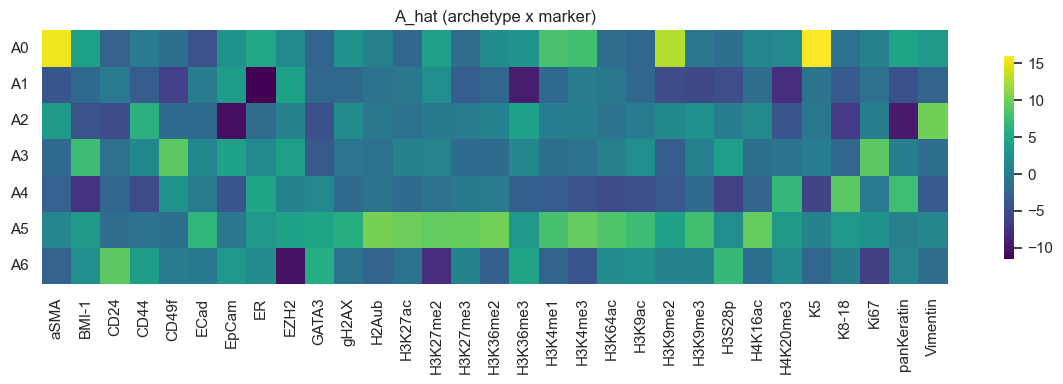

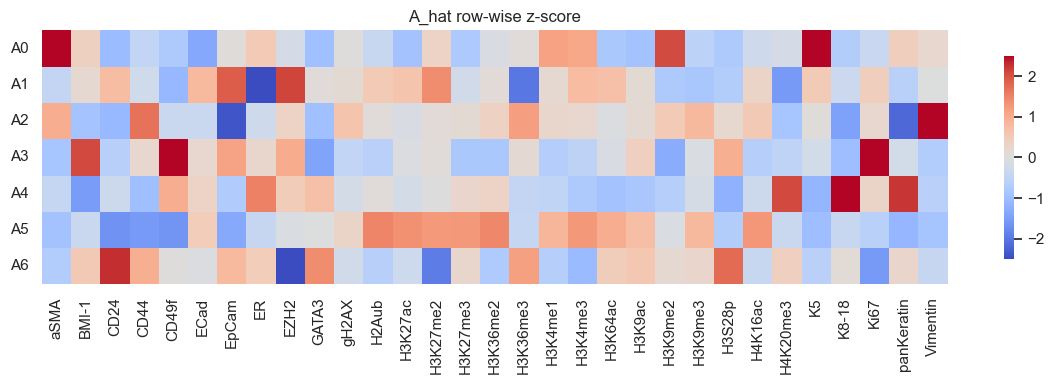

In [20]:
# === B) Archetype profiles ===
plot_matrix_heatmap(
    A_hat,
    row_labels=[f"A{k}" for k in range(A_hat.shape[0])],
    col_labels=marker_names,
    title="A_hat (archetype x marker)",
    cmap="viridis",
    figsize=(max(12, len(marker_names) * 0.35), max(4, A_hat.shape[0] * 0.35)),
)

if ANALYSIS_CFG["row_zscore_archetype_heatmap"]:
    row_mean = A_hat.mean(axis=1, keepdims=True)
    row_std = np.maximum(A_hat.std(axis=1, keepdims=True), 1e-8)
    A_row_z = (A_hat - row_mean) / row_std
    plot_matrix_heatmap(
        A_row_z,
        row_labels=[f"A{k}" for k in range(A_hat.shape[0])],
        col_labels=marker_names,
        title="A_hat row-wise z-score",
        cmap="coolwarm",
        figsize=(max(12, len(marker_names) * 0.35), max(4, A_hat.shape[0] * 0.35)),
        vmin=-2.5,
        vmax=2.5,
    )

ranking_df = archetype_marker_rankings(
    A_hat,
    marker_names=marker_names,
    top_n=int(ANALYSIS_CFG["top_n_markers"]),
)
ranking_path = ANALYSIS_OUTDIR / "archetype_marker_rankings.csv"
ranking_df.to_csv(ranking_path, index=False)
print(f"Saved marker ranking table to: {ranking_path}")

display(ranking_df.head(40))


,n_cells
dominant_archetype,
0,2593
1,26661
2,14372
3,9453
4,28877
5,13506
6,54538


,threshold,fraction_cells
0,0.5,0.00026
1,0.8,0.00000


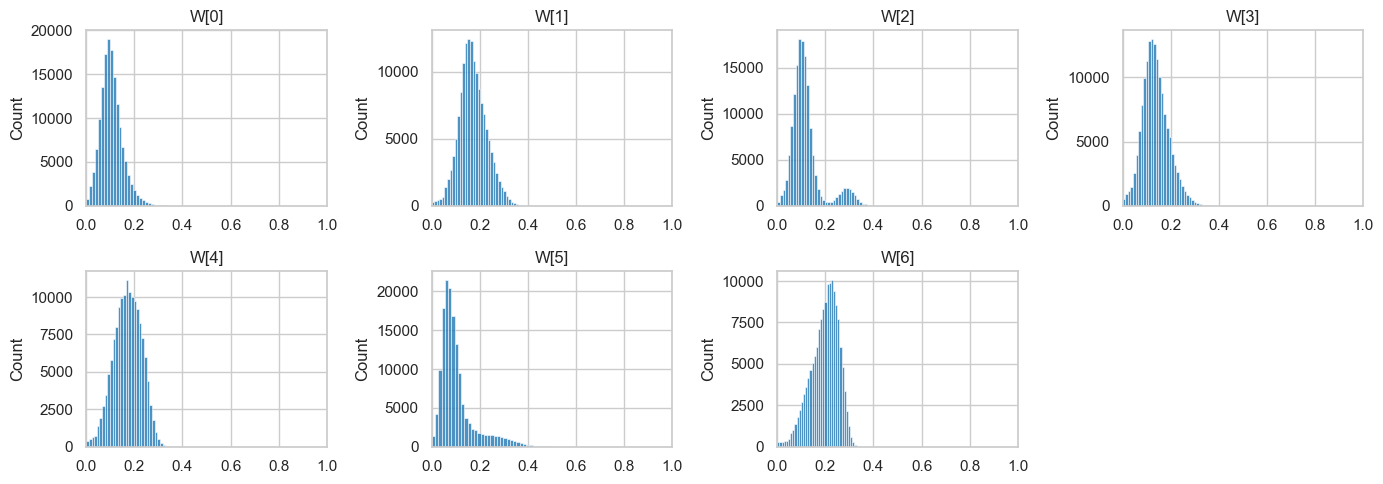

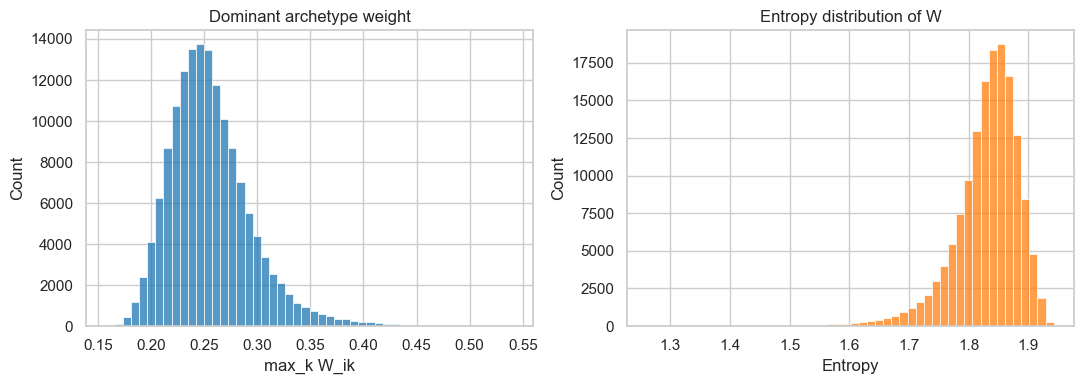

In [21]:
# === C) Per-cell weights ===
plot_weight_histograms(W)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(dom_df["dominant_weight"], bins=50, ax=axes[0], color="tab:blue")
axes[0].set_title("Dominant archetype weight")
axes[0].set_xlabel("max_k W_ik")

sns.histplot(dom_df["entropy"], bins=50, ax=axes[1], color="tab:orange")
axes[1].set_title("Entropy distribution of W")
axes[1].set_xlabel("Entropy")
plt.tight_layout()

dom_counts = dom_df["dominant_archetype"].value_counts().sort_index()
display(dom_counts.to_frame("n_cells"))
display(purity_df)


,sample,archetype_0,archetype_1,archetype_2,archetype_3,archetype_4,archetype_5,archetype_6
0,4.0,0.091334,0.153198,0.110233,0.111506,0.229698,0.081646,0.222385
1,4.1,0.091405,0.153460,0.108164,0.113918,0.228449,0.083501,0.221102
2,5.0,0.099951,0.124025,0.116080,0.122099,0.191613,0.174299,0.171933
3,7.0,0.109315,0.164762,0.119321,0.153143,0.144853,0.091220,0.217384
4,7.1,0.106383,0.160386,0.121376,0.152811,0.144833,0.093827,0.220385


,sample,dominant_archetype,n_cells,fraction
0,4.0,0,16,0.0016
1,4.0,1,353,0.0353
2,4.0,2,65,0.0065
3,4.0,3,18,0.0018
4,4.0,4,5445,0.5445


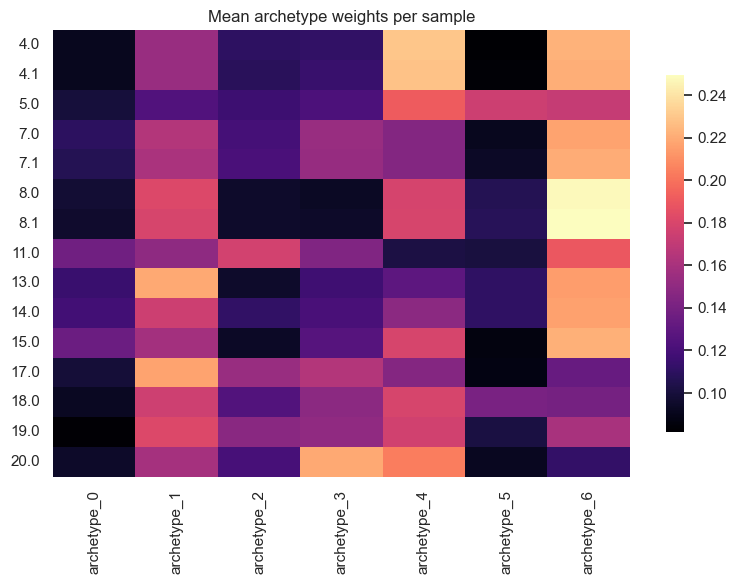

In [22]:
# === D) Sample-level summaries ===
if sample_ids is None:
    print("No sample IDs found in saved outputs; skipping sample-level analysis.")
else:
    sample_stats = summarize_by_group(W, sample_ids, group_name="sample")
    sample_mean = sample_stats["mean_weights"]
    sample_dom = sample_stats["dominant_fractions"]

    display(sample_mean.head())
    display(sample_dom.head())

    sample_mean_matrix = sample_mean.set_index("sample").to_numpy()
    plot_matrix_heatmap(
        sample_mean_matrix,
        row_labels=sample_mean["sample"].astype(str).tolist(),
        col_labels=[c for c in sample_mean.columns if c != "sample"],
        title="Mean archetype weights per sample",
        cmap="magma",
        figsize=(8, max(4, sample_mean.shape[0] * 0.4)),
    )

    # Optional condition-level boxplots if adata + condition column provided.
    if ANALYSIS_CFG["adata_path"] is not None and ANALYSIS_CFG["condition_col"] is not None:
        import anndata as ad

        adata = ad.read_h5ad(ANALYSIS_CFG["adata_path"])
        obs = adata.obs.copy()
        if ANALYSIS_CFG["condition_col"] in obs.columns and "sample" in sample_mean.columns:
            map_df = obs[[ANALYSIS_CFG["condition_col"]]].copy()
            map_df["sample"] = obs.index.astype(str)
            # This assumes sample IDs are comparable to obs index or have been pre-mapped.
            print("Condition boxplots may require custom sample-to-condition mapping for your dataset.")


In [23]:
# === E) Cluster-level summaries ===
if cluster_ids is None:
    print("No cluster IDs found in saved outputs; skipping cluster-level analysis.")
else:
    cluster_stats = summarize_by_group(W, cluster_ids, group_name="cluster")
    cluster_mean = cluster_stats["mean_weights"]
    cluster_dom = cluster_stats["dominant_fractions"]

    display(cluster_mean.head())
    display(cluster_dom.head())

    cluster_mean_matrix = cluster_mean.set_index("cluster").to_numpy()
    plot_matrix_heatmap(
        cluster_mean_matrix,
        row_labels=cluster_mean["cluster"].astype(str).tolist(),
        col_labels=[c for c in cluster_mean.columns if c != "cluster"],
        title="Mean archetype weights per cluster",
        cmap="plasma",
        figsize=(8, max(4, cluster_mean.shape[0] * 0.4)),
    )


No cluster IDs found in saved outputs; skipping cluster-level analysis.


In [24]:
# === F) UMAP overlays ===
umap_xy = None
if ANALYSIS_CFG["adata_path"] is not None:
    try:
        import anndata as ad

        adata = ad.read_h5ad(ANALYSIS_CFG["adata_path"])
        if "X_umap" in adata.obsm:
            umap_df = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names)
            # Align to run cell order if possible.
            common = [c for c in cell_ids if c in umap_df.index]
            if len(common) == len(cell_ids):
                umap_xy = umap_df.loc[cell_ids].to_numpy()
            elif len(common) > 0:
                print("Partial overlap between run cells and adata.obs_names; using matched subset only.")
                keep_mask = np.array([c in umap_df.index for c in cell_ids])
                umap_xy = umap_df.loc[np.array(cell_ids)[keep_mask]].to_numpy()
                W = W[keep_mask]
                dom_df = dom_df.loc[keep_mask].reset_index(drop=True)
            else:
                print("No matching cell IDs between run outputs and adata.obs_names.")
    except Exception as exc:
        print(f"Unable to load UMAP from AnnData: {exc}")

if umap_xy is None:
    print("UMAP unavailable (set ANALYSIS_CFG['adata_path'] with .obsm['X_umap']).")
else:
    n_panels = min(W.shape[1], int(ANALYSIS_CFG["max_umap_panels"]))
    n_cols = 4
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.3 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for k in range(n_panels):
        sc = axes[k].scatter(umap_xy[:, 0], umap_xy[:, 1], c=W[:, k], s=3, cmap="viridis", linewidths=0)
        axes[k].set_title(f"Archetype {k} weight")
        axes[k].set_xlabel("UMAP1")
        axes[k].set_ylabel("UMAP2")
        plt.colorbar(sc, ax=axes[k], fraction=0.046, pad=0.04)
    for j in range(n_panels, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()

    plot_umap_categorical(umap_xy, dom_df["dominant_archetype"].to_numpy(), title="Dominant archetype")
    plot_umap_overlay(umap_xy, dom_df["entropy"].to_numpy(), title="Entropy overlay", cmap="magma")


UMAP unavailable (set ANALYSIS_CFG['adata_path'] with .obsm['X_umap']).


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


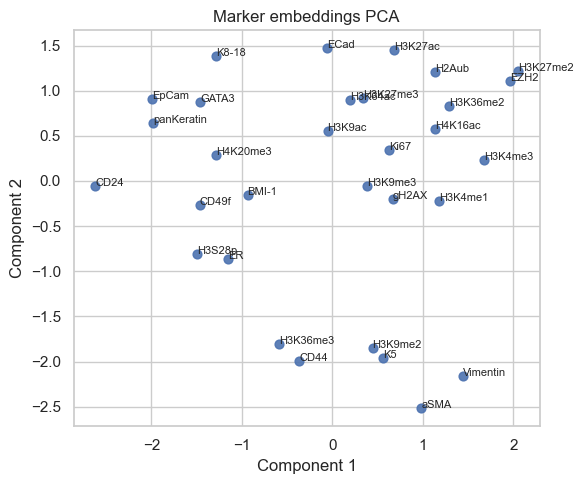

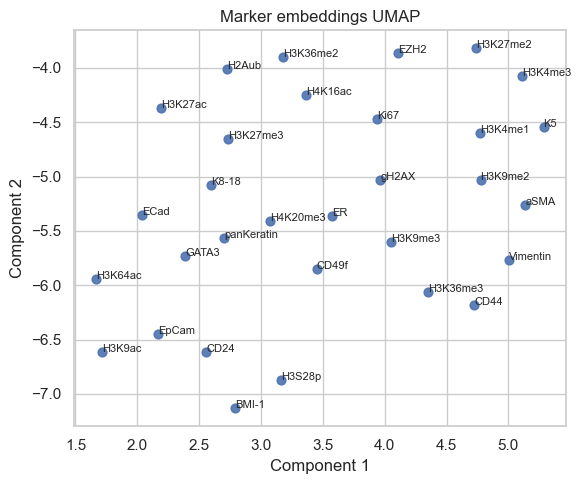

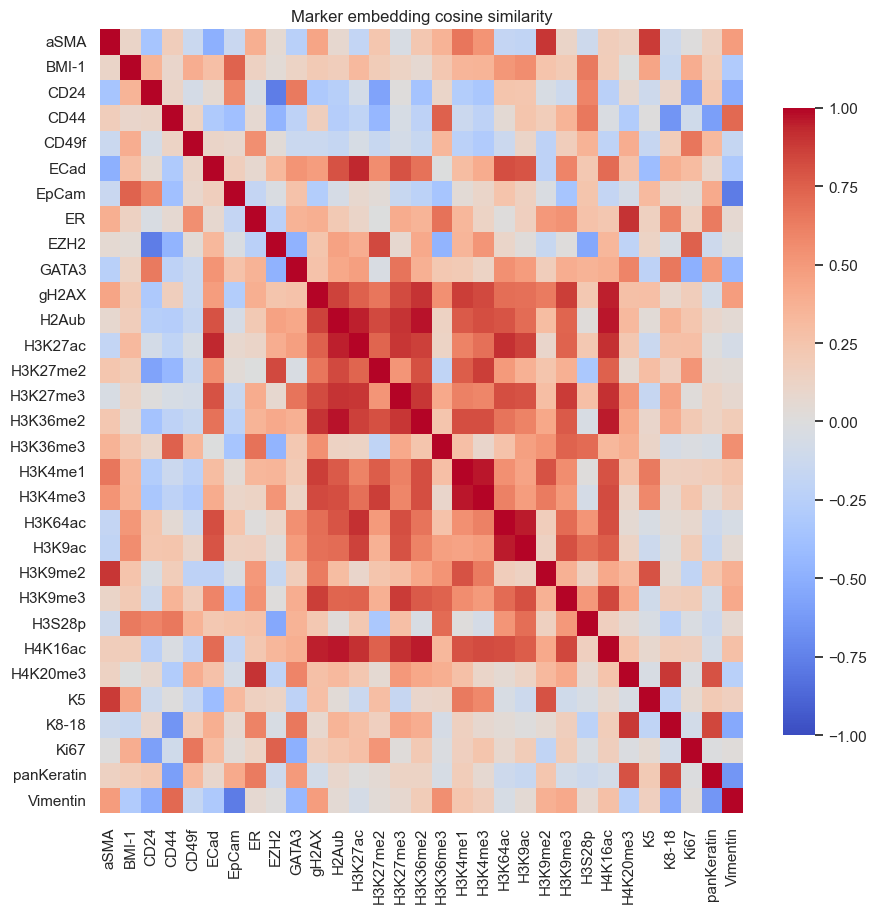

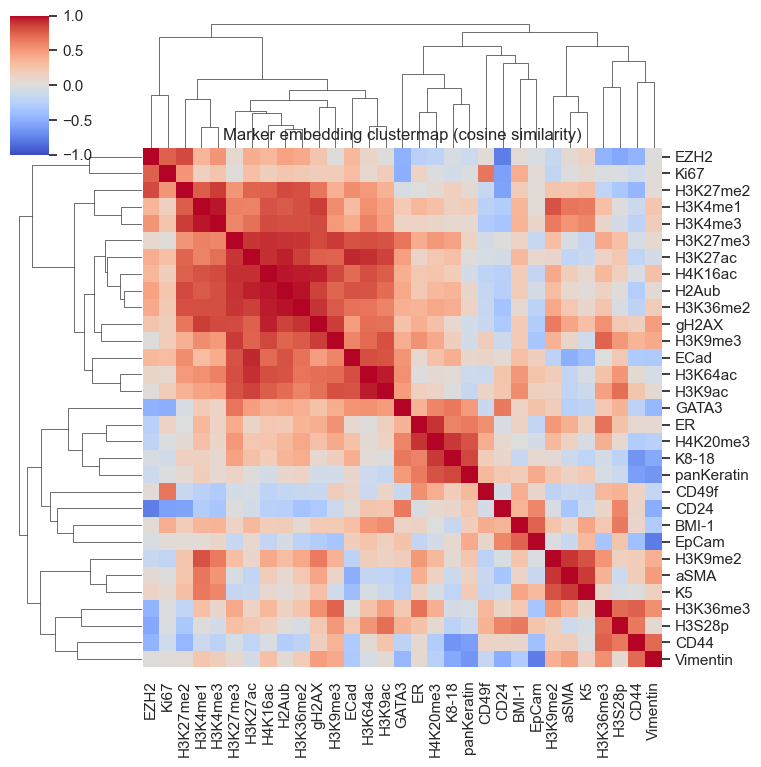

Saved marker nearest-neighbor table to: outputs/breast_vim_archetype_embedding_analysis/marker_embedding_neighbors.csv


,query,rank,neighbor,similarity
0,aSMA,1,H3K9me2,0.893993
1,aSMA,2,K5,0.879173
2,aSMA,3,H3K4me1,0.661154
3,aSMA,4,H3K4me3,0.529128
4,aSMA,5,Vimentin,0.491754
5,aSMA,6,gH2AX,0.438801
6,aSMA,7,ER,0.384650
7,aSMA,8,H3K36me3,0.361969
8,BMI-1,1,EpCam,0.735697
9,BMI-1,2,H3S28p,0.641411


In [25]:
# === G) Marker embedding analysis (E) ===
E = run.get("E")
if E is None:
    print("This run uses direct decoder; marker embedding matrix E is unavailable.")
else:
    E_pca = pca_projection(E, n_components=2)
    plot_embedding_scatter(E_pca, labels=marker_names, title="Marker embeddings PCA")

    E_umap = umap_projection(E, n_neighbors=min(10, max(2, E.shape[0] - 1)), min_dist=0.1, random_state=7)
    if E_umap is not None:
        plot_embedding_scatter(E_umap, labels=marker_names, title="Marker embeddings UMAP")
    else:
        print("umap-learn not installed; skipping marker embedding UMAP.")

    marker_sim = cosine_similarity_matrix(E)
    plot_matrix_heatmap(
        marker_sim,
        row_labels=marker_names,
        col_labels=marker_names,
        title="Marker embedding cosine similarity",
        cmap="coolwarm",
        figsize=(max(8, len(marker_names) * 0.3), max(6, len(marker_names) * 0.3)),
        vmin=-1,
        vmax=1,
    )

    plot_clustermap(
        marker_sim,
        row_labels=marker_names,
        col_labels=marker_names,
        title="Marker embedding clustermap (cosine similarity)",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        figsize=(max(7, len(marker_names) * 0.25), max(7, len(marker_names) * 0.25)),
        metric="euclidean",
        method="average",
    )

    nn_df = nearest_neighbors_from_similarity(marker_sim, marker_names, k=min(8, max(1, len(marker_names) - 1)))
    nn_path = ANALYSIS_OUTDIR / "marker_embedding_neighbors.csv"
    nn_df.to_csv(nn_path, index=False)
    print(f"Saved marker nearest-neighbor table to: {nn_path}")
    display(nn_df.head(40))


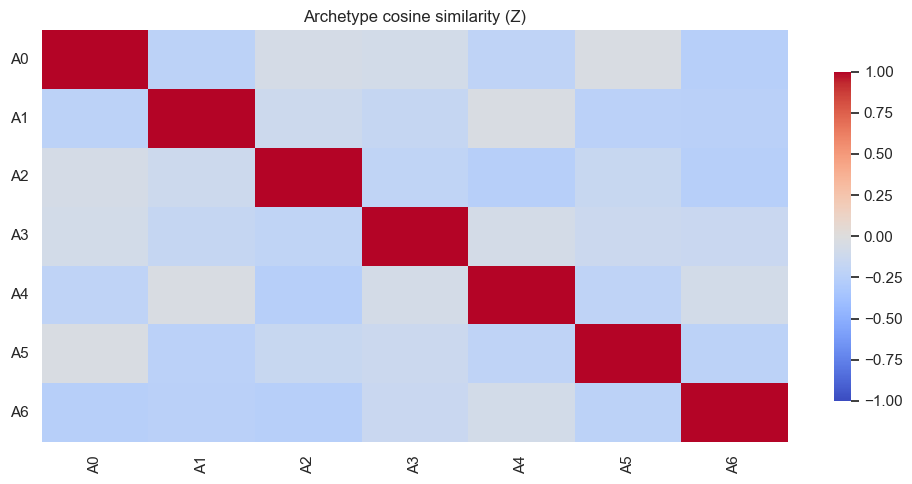

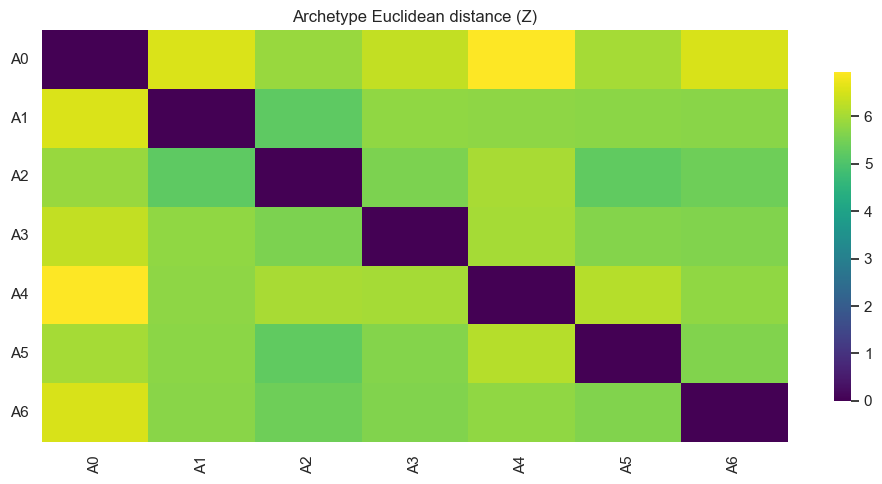

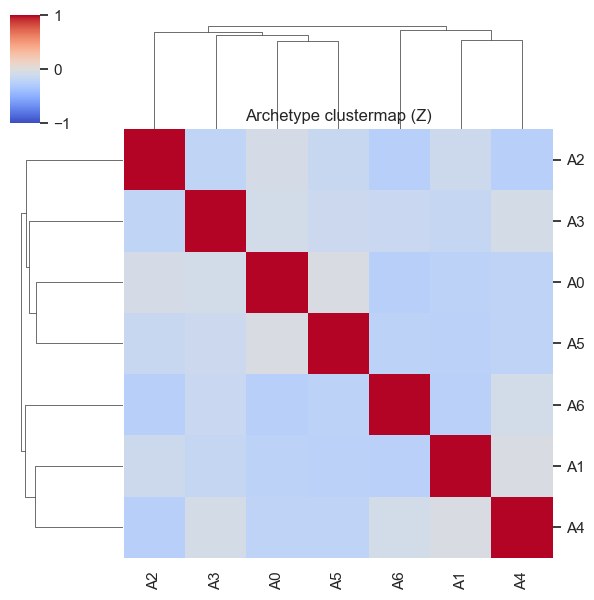

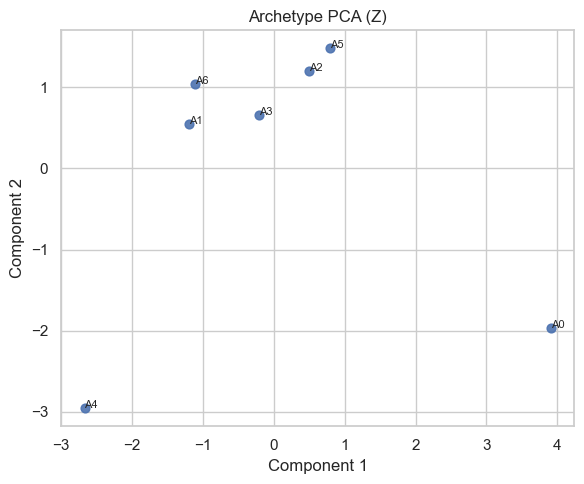

In [26]:
# === H) Archetype embedding analysis (Z) ===
if run.get("Z") is not None:
    archetype_repr = run["Z"]
    repr_name = "Z"
else:
    archetype_repr = A_hat
    repr_name = "A_hat (direct archetype profiles)"

arch_sim = cosine_similarity_matrix(archetype_repr)
arch_dist = pairwise_distance_matrix(archetype_repr)

labels = [f"A{k}" for k in range(archetype_repr.shape[0])]
plot_matrix_heatmap(arch_sim, row_labels=labels, col_labels=labels, title=f"Archetype cosine similarity ({repr_name})", cmap="coolwarm", vmin=-1, vmax=1)
plot_matrix_heatmap(arch_dist, row_labels=labels, col_labels=labels, title=f"Archetype Euclidean distance ({repr_name})", cmap="viridis")

plot_clustermap(
    arch_sim,
    row_labels=labels,
    col_labels=labels,
    title=f"Archetype clustermap ({repr_name})",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    figsize=(6, 6),
    metric="euclidean",
    method="average",
)

arch_pca = pca_projection(archetype_repr, n_components=2)
plot_embedding_scatter(arch_pca, labels=labels, title=f"Archetype PCA ({repr_name})")


Saved residual summary to: outputs/breast_vim_archetype_embedding_analysis/residual_marker_summary.csv


,marker,residual_mean,residual_std,residual_mae,residual_mse
0,gH2AX,-0.000343,0.850264,0.646834,0.722949
1,CD44,0.002863,0.780892,0.571764,0.609801
2,ECad,-0.002050,0.767443,0.573781,0.588972
3,CD49f,0.000123,0.719968,0.553214,0.518354
4,H3S28p,0.000190,0.710929,0.557279,0.505419
5,Ki67,0.003164,0.696533,0.504020,0.485168
6,CD24,-0.004142,0.675840,0.545038,0.456778
7,H3K4me1,-0.001359,0.650303,0.498448,0.422896
8,H3K36me3,-0.000512,0.642429,0.500699,0.412715
9,H3K9ac,0.000967,0.640189,0.488078,0.409842


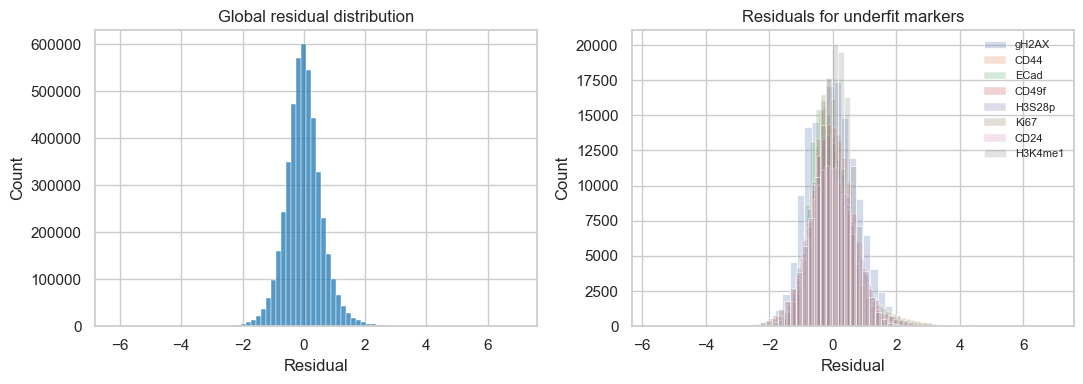

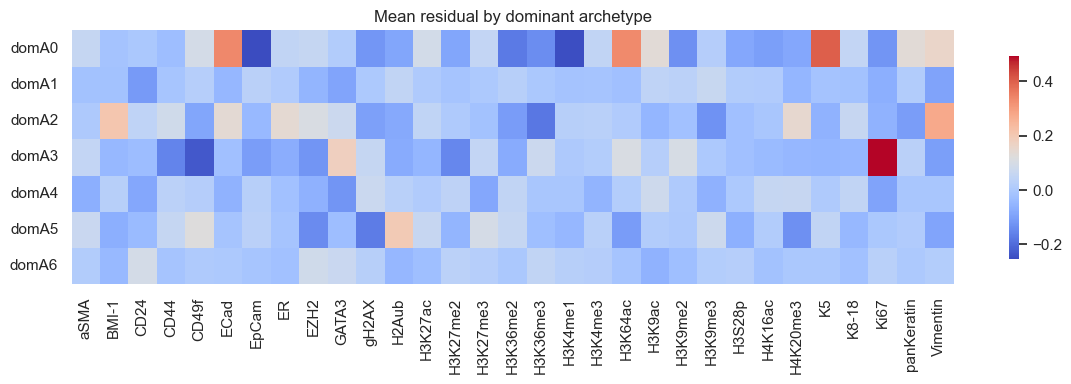

In [27]:
# === I) Residual analysis ===
res_df = residual_summary(X, X_hat, marker_names)
res_path = ANALYSIS_OUTDIR / "residual_marker_summary.csv"
res_df.to_csv(res_path, index=False)
print(f"Saved residual summary to: {res_path}")

display(res_df.head(25))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot((X - X_hat).ravel(), bins=80, ax=axes[0], color="tab:blue")
axes[0].set_title("Global residual distribution")
axes[0].set_xlabel("Residual")

worst_markers = res_df.head(min(8, len(res_df)))["marker"].tolist()
idx_map = {m: i for i, m in enumerate(marker_names)}
for marker in worst_markers:
    m = idx_map[marker]
    sns.histplot((X[:, m] - X_hat[:, m]), bins=50, ax=axes[1], alpha=0.25, label=marker)
axes[1].set_title("Residuals for underfit markers")
axes[1].set_xlabel("Residual")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()

# Optional residual heatmap by dominant archetype.
residual = X - X_hat
dom = np.argmax(W, axis=1)
res_by_dom = np.vstack([residual[dom == k].mean(axis=0) if np.any(dom == k) else np.zeros(X.shape[1]) for k in range(W.shape[1])])
plot_matrix_heatmap(
    res_by_dom,
    row_labels=[f"domA{k}" for k in range(W.shape[1])],
    col_labels=marker_names,
    title="Mean residual by dominant archetype",
    cmap="coolwarm",
    figsize=(max(12, len(marker_names) * 0.35), max(4, W.shape[1] * 0.3)),
)
